In [4]:
import os
original_omp_threads = os.environ.get('OMP_NUM_THREADS', None)
os.environ['OMP_NUM_THREADS'] = '1'

import galsim
import batsim
import anacal
import numpy as np
import matplotlib.pyplot as plt
import fitsio

from multiprocessing import cpu_count
from parallelbar import progress_starmap
from scipy.stats import gaussian_kde
from tqdm import tqdm
from time import time

from importlib import reload
reload(batsim)

<module 'batsim' from '/home/b7009348/FPFS-project/BATSim/src/batsim/__init__.py'>

In [5]:
def cancel_shape_noise(gal_obj, nrot):
    '''Create nrot rotated versions of the input galaxy object
    such that shape noise cancels out when averaging the shapes'''
    rotated_gals = []
    for i in range(nrot):
        rot_ang = np.pi / nrot * i
        ang = rot_ang * galsim.radians
        rotated_gals.append(gal_obj.rotate(ang))
        
    return rotated_gals

def measure_shear(gal_array, psf_array, npix, pixel_scale, noise_variance, noise_array, detection):
    '''Measure the shear using FPFS and return catalog'''
    fpfs_config = anacal.fpfs.FpfsConfig(
        sigma_shapelets=0.52,  # The first measurement scale (also for detection)
        sigma_shapelets2=0.45,  # The second measurement scale
        npix=npix # individual stamp size for basis operations
    )
    
    catalog = anacal.fpfs.process_image(
        fpfs_config=fpfs_config,
        mag_zero=30.0,
        gal_array=gal_array,
        psf_array=psf_array,
        pixel_scale=pixel_scale,
        noise_variance=max(noise_variance, 0.23),
        noise_array=noise_array,
        detection=detection,
    )

    return catalog

def batsim_generate_images(
        gal,
        nn,
        scale,
        psf,
        lens_shear,
        n_rot,
        max_supersample=64,
        compensate_integration="sinc"
    ):

    rotated_gals = cancel_shape_noise(gal, n_rot)

    stamp_size = nn * np.sqrt(n_rot)
    stamp = galsim.ImageF(stamp_size, stamp_size, scale=scale)

    LensTransform = batsim.LensTransform(gamma1=lens_shear, gamma2=0, kappa=0)
    
    for j in range(n_rot):
        # set drawing location on image
        row = j // int(np.sqrt(n_rot))
        col = j % int(np.sqrt(n_rot))

        # Compute the bounds for this galaxy
        xmin = col * nn + 1  # +1 because GalSim coordinates start at 1
        xmax = (col + 1) * nn
        ymin = row * nn + 1
        ymax = (row + 1) * nn

        gal_img = batsim.simulate_galaxy(
            gal_obj=rotated_gals[j],
            ngrid=nn,
            scale=scale,
            transform_obj=LensTransform,
            psf_obj=psf,
            draw_method="auto",
            backend="numpy",
            max_supersample=max_supersample
        )

        # Set the subimage in the stamp
        bounds = galsim.BoundsI(xmin, xmax, ymin, ymax)
        sub_image = galsim.Image(gal_img, scale=scale)
        stamp[bounds] = sub_image

    return stamp

def galsim_generate_images(gal, nn, scale, psf, lens_shear, n_rot):

    gamma1 = lens_shear
    gamma2 = 0
    kappa = 0 

    g1 = gamma1 / (1 - kappa)
    g2 = gamma2 / (1 - kappa)
    mu = 1 / ((1 - kappa) ** 2 - gamma1**2 - gamma2**2)

    rotated_gals = cancel_shape_noise(gal, n_rot)

    stamp_size = nn * np.sqrt(n_rot)
    stamp = galsim.ImageF(stamp_size, stamp_size, scale=scale)
    
    for j in range(n_rot):
        # set drawing location on image
        row = j // int(np.sqrt(n_rot))
        col = j % int(np.sqrt(n_rot))

        # Compute the bounds for this galaxy
        xmin = col * nn + 1  # +1 because GalSim coordinates start at 1
        xmax = (col + 1) * nn
        ymin = row * nn + 1
        ymax = (row + 1) * nn

        shear_gal = rotated_gals[j].lens(g1=g1, g2=g2, mu=mu)
        conv_gal = galsim.Convolve([shear_gal, psf])
        #conv_gal = conv_gal.shift(0.5*scale, 0.5*scale)
        sub_image = conv_gal.drawImage(
            nx=nn,
            ny=nn,
            scale=scale,
            method="auto"
        )

        # Set the subimage in the stamp
        bounds = galsim.BoundsI(xmin, xmax, ymin, ymax)
        stamp[bounds] = sub_image

    return stamp

def build_large_stamp(tiles, scale, tiles_per_side):

    tile_size = np.shape(tiles[0].array)
    if tile_size[0] != tile_size[1]:
        raise ValueError("Image tiles must be square")

    tile_size = tile_size[0]
    large_size = tile_size * tiles_per_side
    large_stamp = galsim.ImageF(large_size, large_size, scale=scale)

    for i, tile in enumerate(tiles):

        tile_row = i // tiles_per_side
        tile_col = i % tiles_per_side

        xmin = tile_col * tile_size + 1
        xmax = (tile_col + 1) * tile_size
        ymin = tile_row * tile_size + 1
        ymax = (tile_row + 1) * tile_size

        bounds = galsim.BoundsI(xmin, xmax, ymin, ymax)
        large_stamp[bounds] = tile

    return large_stamp

# Test Full Cosmos Sample 

In [2]:
np.random.seed(14)

# Load cosmos catalog
cosmos = galsim.COSMOSCatalog()
print(len(cosmos))

# Image pixel scale in arcsec/pixel
scale = 0.2
nn = 96
lens_shear = 0.02
n_rot = 4

n_gal_stamp = 1600
stamp_size = int(nn * np.sqrt(n_rot * n_gal_stamp))
print(stamp_size)

n_stamps = int(np.ceil(len(cosmos) / n_gal_stamp))
print(n_stamps)

all_inds = np.arange(len(cosmos))
stamp_inds = np.array_split(all_inds, n_stamps)

stamp_galaxies = []
for inds in stamp_inds:
    if len(inds) == 0:
        continue

    galaxies = cosmos.makeGalaxy(index=inds, gal_type='parametric')
    records = cosmos.getParametricRecord(index=inds)

    # re-scale flux to match LSST
    fluxes = 10 ** ((30 - records["mag_auto"]) / 2.5)
    galaxies = [gal.withFlux(flux) for gal, flux in zip(galaxies, fluxes)]

    stamp_galaxies.append(galaxies)

# Define the PSF
psf = galsim.Moffat(beta=3.5, fwhm=0.7)
psf_array = psf.drawImage(nx=nn, ny=nn, scale=scale).array

81499
7680
51


In [ ]:
batsim_stamps = [] # list to store stamps
galsim_stamps = []

use_stamps = 10
if use_stamps > n_stamps:
    raise ValueError("Cannot use more stamps than have been assigned")

clobber=False
for i in tqdm(range(use_stamps)):

    # Assign filenames for tile
    batsim_file = os.path.join(
        "COSMOS_lensed", 
        f"batsim_stamp_{i}_{stamp_size}x{stamp_size}.fits"
    )

    galsim_file = os.path.join(
        "COSMOS_lensed", 
        f"galsim_stamp_{i}_{stamp_size}x{stamp_size}.fits"
    )

    # append function args into list for parallel processing
    args_list = [(gal, nn, scale, psf, lens_shear, n_rot) for gal in stamp_galaxies[i]]

    # check for existing stamp file
    if os.path.exists(batsim_file) and not clobber:
        batsim_stamps.append(galsim.fits.read(file_name=batsim_file))
    else:
        # simulate individual galaxy tiles
        batsim_tiles = progress_starmap(
            batsim_generate_images,
            args_list,
            n_cpu=56
        )

        # assemble tiles into full stamp
        batsim_stamps.append(build_large_stamp(
            tiles=batsim_tiles,
            scale=scale,
            tiles_per_side=40
        ))

        # write stamp to disk
        galsim.fits.write(batsim_stamps[i], file_name=batsim_file)

    # check for existing stamp file
    if os.path.exists(galsim_file) and not clobber:
        galsim_stamps.append(galsim.fits.read(file_name=galsim_file))
    else:
        # simulate individual galaxy tiles
        galsim_tiles = progress_starmap(
            galsim_generate_images,
            args_list,
            n_cpu=56
        )

        # assemble tiles into full stamp
        galsim_stamps.append(build_large_stamp(
            tiles=galsim_tiles,
            scale=scale,
            tiles_per_side=40
        ))

        # write stamp to disk
        galsim.fits.write(galsim_stamps[i], file_name=galsim_file)

  0%|          | 0/10 [00:00<?, ?it/s]

DONE:   0%|          | 0/1599 [00:00<?, ?it/s]

DONE:   0%|          | 0/1599 [00:00<?, ?it/s]

 10%|█         | 1/10 [02:03<18:28, 123.17s/it]

DONE:   0%|          | 0/1598 [00:00<?, ?it/s]

...

DONE:   0%|          | 0/1598 [00:00<?, ?it/s]

 90%|█████████ | 9/10 [19:40<02:10, 130.40s/it]

DONE:   0%|          | 0/1598 [00:00<?, ?it/s]

DONE:   0%|          | 0/1598 [00:00<?, ?it/s]

100%|██████████| 10/10 [22:08<00:00, 132.89s/it]


In [5]:
e1_bt = np.array([])
R1_bt = np.array([])

for stamp in tqdm(batsim_stamps):
    bt_catalog = measure_shear(
            gal_array=stamp.array,
            psf_array=psf_array,
            pixel_scale=scale,
            npix=nn,
            noise_variance=0.23, 
            noise_array=None,
            detection=None
        )

    e1_tile = bt_catalog["fpfs_w"] * bt_catalog["fpfs_e1"] # per-galaxy e1
    R1_tile = (
        bt_catalog["fpfs_dw_dg1"] * bt_catalog["fpfs_e1"]
        + bt_catalog["fpfs_w"] * bt_catalog["fpfs_de1_dg1"] # per-galaxy responses
    )

    e1_bt = np.concatenate([e1_bt, e1_tile])
    R1_bt = np.concatenate([R1_bt, R1_tile])

g1_bt = np.sum(e1_bt) / np.sum(R1_bt) # sample level g1
mbias_bt = g1_bt / lens_shear - 1 # multiplicative bias

print(f"Measured g1: {g1_bt}")
print(f"Multiplicative bias: {mbias_bt}")

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [01:22<00:00,  8.23s/it]

Measured g1: 0.0200221309633825
Multiplicative bias: 0.0011065481691250323


In [6]:
e1_gs = np.array([])
R1_gs = np.array([])

for stamp in tqdm(galsim_stamps):
    gs_catalog = measure_shear(
            gal_array=stamp.array,
            psf_array=psf_array,
            pixel_scale=scale,
            npix=nn,
            noise_variance=0.23, 
            noise_array=None,
            detection=None
        )

    e1_tile = gs_catalog["fpfs_w"] * gs_catalog["fpfs_e1"] # per-galaxy e1 (weighted)
    R1_tile = (
        gs_catalog["fpfs_dw_dg1"] * gs_catalog["fpfs_e1"]
        + gs_catalog["fpfs_w"] * gs_catalog["fpfs_de1_dg1"] # per-galaxy responses
    )

    e1_gs = np.concatenate([e1_gs, e1_tile])
    R1_gs = np.concatenate([R1_gs, R1_tile])

g1_gs = np.sum(e1_gs) / np.sum(R1_gs) # sample level g1
mbias_gs = g1_gs / lens_shear - 1 # multiplicative bias

print(f"Measured g1: {g1_gs}")
print(f"Multiplicative bias: {mbias_gs}")

100%|██████████| 10/10 [01:21<00:00,  8.12s/it]

Measured g1: 0.020000115992198704
Multiplicative bias: 5.799609935186467e-06


In [7]:
# pickle catalog:
import pickle

with open("fpfs_catalog_tile_51.pkl", "wb") as file:
    pickle.dump(gs_catalog, file)

with open("fpfs_catalog_tile_51.pkl", "rb") as file:
    test_cat = pickle.load(file)

print(len(test_cat["fpfs_e1"]))

6396


In [8]:
stamp_totals = np.sum([len(stamp_inds[i])*n_rot for i in range(use_stamps)])
print(stamp_totals)

gs_total = len(e1_gs)
gs_failed = len(np.where(e1_gs == 0)[0])
gs_undetected = stamp_totals - gs_total
print(f"Total GalSim: {gs_total}")
print(f"Zero-weight GalSim: {gs_failed}")
print(f"Undetected: {gs_undetected}")

print("--------------------------------------")

bt_total = len(e1_bt)
bt_failed = len(np.where(e1_bt == 0)[0])
bt_undetected = stamp_totals - bt_total
print(f"Total BATSim: {bt_total}")
print(f"Zero-weight BATSim: {bt_failed}")
print(f"Undetected: {bt_undetected}")

63924
Total GalSim: 63959
Zero-weight GalSim: 12728
Undetected: -35
--------------------------------------
Total BATSim: 63959
Zero-weight BATSim: 12579
Undetected: -35


In [9]:
def plot_kde_1d(x, label=None, gridsize=512, bw='scott'):
    x = np.asarray(x)
    x = x[np.isfinite(x)]

    kde = gaussian_kde(x, bw_method=bw)
    xs = np.linspace(x.min(), x.max(), gridsize)
    ys = kde(xs)

    plt.plot(xs, ys, label=label)

g1 absolute diff: 2.2014971183797333e-05
mbias absolute diff 0.0011007485591898458


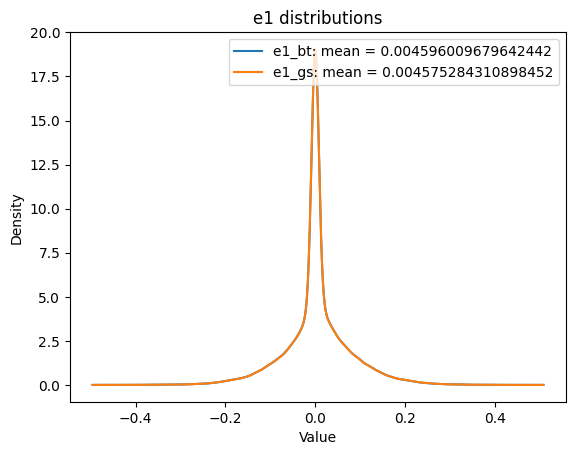

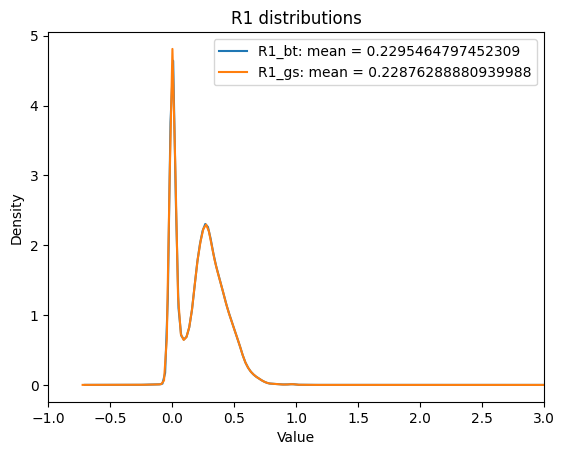

In [10]:
# Compare BATSim and Galsim results
print(f"g1 absolute diff: {abs(g1_gs - g1_bt)}")
print(f"mbias absolute diff {abs(mbias_gs - mbias_bt)}")

plt.figure()
plot_kde_1d(e1_bt, label=f"e1_bt: mean = {np.mean(e1_bt)}")
plot_kde_1d(e1_gs, label=f"e1_gs: mean = {np.mean(e1_gs)}")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.title("e1 distributions")
plt.show()

plt.figure()
plot_kde_1d(R1_bt, label=f"R1_bt: mean = {np.mean(R1_bt)}")
plot_kde_1d(R1_gs, label=f"R1_gs: mean = {np.mean(R1_gs)}")
plt.xlabel("Value")
plt.ylabel("Density")
plt.xlim([-1,3])
plt.legend()
plt.title("R1 distributions")
plt.show()

In [11]:
def measure_all_tiles(
        stamps,
        psf_array,
        scale,
        nn,
        noise_variance
    ):

    E_tiles = []
    R_tiles = []

    for stamp in tqdm(stamps):
        cat = measure_shear(
            gal_array=stamp.array,
            psf_array=psf_array,
            pixel_scale=scale,
            npix=nn,
            noise_variance=noise_variance,
            noise_array=None,
            detection=None,
        )

        e = cat["fpfs_w"] * cat["fpfs_e1"]
        R = (
            cat["fpfs_dw_dg1"] * cat["fpfs_e1"]
            + cat["fpfs_w"] * cat["fpfs_de1_dg1"]
        )

        E_tiles.append(np.sum(e))
        R_tiles.append(np.sum(R))

    return E_tiles, R_tiles

def jackknife_over_tiles(
    E_tiles,
    R_tiles,
    lens_shear
):

    E_tiles = np.asarray(E_tiles)
    R_tiles = np.asarray(R_tiles)

    E_tot = E_tiles.sum()
    R_tot = R_tiles.sum()

    g1 = E_tot / R_tot
    m = g1 / lens_shear - 1

    n = len(E_tiles)
    g1_loo = (E_tot - E_tiles) / (R_tot - R_tiles)
    m_loo = g1_loo / lens_shear - 1

    g1_err = np.sqrt((n - 1) / n * np.sum((g1_loo - g1_loo.mean()) ** 2))
    m_err = np.sqrt((n - 1) / n * np.sum((m_loo - m_loo.mean()) ** 2))

    return {
        "g1": g1,
        "g1_err": g1_err,
        "m": m,
        "m_err": m_err,
        "E_tiles": E_tiles,
        "R_tiles": R_tiles,
        "g1_loo": g1_loo,
        "m_loo": m_loo,
    }

In [12]:
E_tiles_gs, R_tiles_gs = measure_all_tiles(
    stamps=galsim_stamps,
    psf_array=psf_array,
    scale=scale,
    nn=nn,
    noise_variance=0.23
)

E_tiles_bt, R_tiles_bt = measure_all_tiles(
    stamps=batsim_stamps,
    psf_array=psf_array,
    scale=scale,
    nn=nn,
    noise_variance=0.23
)

100%|██████████| 10/10 [01:21<00:00,  8.13s/it]


In [13]:
res_jk_gs = jackknife_over_tiles(
    E_tiles_gs,
    R_tiles_gs,
    lens_shear
)

print(f"Measured g1: {res_jk_gs['g1']} ± {res_jk_gs['g1_err']}")
print(f"Multiplicative bias: {res_jk_gs['m']} ± {res_jk_gs['m_err']}")

Measured g1: 0.020000115992198707 ± 3.676305561432209e-05
Multiplicative bias: 5.799609935408512e-06 ± 0.001838152780716115


In [14]:
res_jk_bt = jackknife_over_tiles(
    E_tiles_bt,
    R_tiles_bt,
    lens_shear
)

print(f"Measured g1: {res_jk_bt['g1']} ± {res_jk_bt['g1_err']}")
print(f"Multiplicative bias: {res_jk_bt['m']} ± {res_jk_bt['m_err']}")

Measured g1: 0.020022130963382498 ± 3.438115950358075e-05
Multiplicative bias: 0.0011065481691248102 ± 0.0017190579751790941


In [15]:
def bootstrap_tiles(E_tiles, R_tiles, lens_shear, n_boot=1000, rng=None):
    E_tiles = np.asarray(E_tiles)
    R_tiles = np.asarray(R_tiles)

    n_tiles = len(E_tiles)
    rng = np.random.default_rng(rng)

    g_boot = np.empty(n_boot)
    m_boot = np.empty(n_boot)

    for b in range(n_boot):
        inds = rng.integers(0, n_tiles, size=n_tiles)  # sample tiles with replacement
        E = E_tiles[inds].sum()
        R = R_tiles[inds].sum()

        g = E / R
        m = g / lens_shear - 1

        g_boot[b] = g
        m_boot[b] = m

    g_hat = E_tiles.sum() / R_tiles.sum()
    m_hat = g_hat / lens_shear - 1

    g_err = g_boot.std(ddof=1)
    m_err = m_boot.std(ddof=1)

    g_ci = np.percentile(g_boot, [16, 84])
    m_ci = np.percentile(m_boot, [16, 84])

    return {
        "g1": g_hat,
        "m": m_hat,
        "g1_err": g_err,
        "m_err": m_err,
        "g1_boot": g_boot,
        "m_boot": m_boot,
        "g1_ci_16_84": g_ci,
        "m_ci_16_84": m_ci,
    }

In [16]:
res_boot_gs = bootstrap_tiles(
    E_tiles_gs,
    R_tiles_gs,
    lens_shear
)

print(f"Measured g1: {res_boot_gs['g1']} ± {res_boot_gs['g1_err']}")
print(f"Multiplicative bias: {res_boot_gs['m']} ± {res_boot_gs['m_err']}")

Measured g1: 0.020000115992198707 ± 3.438764288862933e-05
Multiplicative bias: 5.799609935408512e-06 ± 0.0017193821444314635


In [17]:
res_boot_bt = bootstrap_tiles(
    E_tiles_bt,
    R_tiles_bt,
    lens_shear
)

print(f"Measured g1: {res_boot_bt['g1']} ± {res_boot_bt['g1_err']}")
print(f"Multiplicative bias: {res_boot_bt['m']} ± {res_boot_bt['m_err']}")

Measured g1: 0.020022130963382498 ± 3.229161068912157e-05
Multiplicative bias: 0.0011065481691248102 ± 0.0016145805344560775


# Test Only Difficult Galaxies

In [6]:
# Load indicies of the hard galaxies
hard_inds = np.load("cosmos_indices_of_interest.npz")
print(hard_inds.keys())

# concatenate all hard galaxy indices into a single array with no duplicates
all_hard = np.unique(np.concatenate([hard_inds[key] for key in hard_inds.keys()]))

cosmos = galsim.COSMOSCatalog()
cosmos_all_hard = cosmos.makeGalaxy(index=all_hard, gal_type='parametric')
cosmos_low_re = cosmos.makeGalaxy(index=hard_inds["low_re"], gal_type='parametric')
cosmos_sersic7 = cosmos.makeGalaxy(index=hard_inds["sersic7"], gal_type='parametric')
cosmos_sersic7_low_re = cosmos.makeGalaxy(index=hard_inds["sersic7_low_re"], gal_type='parametric')

print(f"Total unique hard galaxies: {len(cosmos_all_hard)}")
print(f"Low R_e galaxies: {len(cosmos_low_re)}")
print(f"Sersic 7 galaxies: {len(cosmos_sersic7)}")
print(f"Sersic 7 Low R_e galaxies: {len(cosmos_sersic7_low_re)}")

KeysView(NpzFile 'cosmos_indices_of_interest.npz' with keys: sersic7, low_re, sersic7_low_re)
Total unique hard galaxies: 11946
Low R_e galaxies: 10670
Sersic 7 galaxies: 2390
Sersic 7 Low R_e galaxies: 1114


In [7]:
print(hard_inds["sersic7"])
print(hard_inds["low_re"])
print(hard_inds["sersic7_low_re"])
print(all_hard)

[   15    37    46 ... 81430 81483 81487]
[    1    15    18 ... 81483 81487 81491]
[   15    63    92 ... 81404 81483 81487]
[    1    15    18 ... 81483 81487 81491]


In [8]:
cosmos_set = all_hard

# Image pixel scale in arcsec/pixel
scale = 0.2
nn = 96
lens_shear = 0.02
n_rot = 4

n_gal_stamp = 1600
stamp_size = int(nn * np.sqrt(n_rot * n_gal_stamp))
print(stamp_size)

n_stamps = int(np.ceil(len(cosmos_set) / n_gal_stamp))
print(n_stamps)

all_inds = np.arange(len(cosmos_set))
stamp_inds = np.array_split(all_inds, n_stamps)

stamp_galaxies = []
for inds in stamp_inds:
    if len(inds) == 0:
        continue

    galaxies = cosmos.makeGalaxy(index=inds, gal_type='parametric')
    records = cosmos.getParametricRecord(index=inds)

    # re-scale flux to match LSST
    fluxes = 10 ** ((30 - records["mag_auto"]) / 2.5)
    galaxies = [gal.withFlux(flux) for gal, flux in zip(galaxies, fluxes)]

    stamp_galaxies.append(galaxies)

# Define the PSF
psf = galsim.Moffat(beta=3.5, fwhm=0.7)
psf_array = psf.drawImage(nx=nn, ny=nn, scale=scale).array

7680
8


In [9]:
batsim_stamps = [] # list to store stamps
galsim_stamps = []

for i in tqdm(range(len(stamp_galaxies))):
    # append function args into list for parallel processing
    args_list = [(gal, nn, scale, psf, lens_shear, n_rot) for gal in stamp_galaxies[i]]

    # simulate individual galaxy tiles
    batsim_tiles = progress_starmap(
        batsim_generate_images,
        args_list,
        n_cpu=56
    )

    # assemble tiles into full stamp
    batsim_stamps.append(build_large_stamp(
        tiles=batsim_tiles,
        scale=scale,
        tiles_per_side=40
    ))

    # simulate individual galaxy tiles
    galsim_tiles = progress_starmap(
        galsim_generate_images,
        args_list,
        n_cpu=56
    )

    # assemble tiles into full stamp
    galsim_stamps.append(build_large_stamp(
        tiles=galsim_tiles,
        scale=scale,
        tiles_per_side=40
    ))

  0%|          | 0/8 [00:00<?, ?it/s]

DONE:   0%|          | 0/1494 [00:00<?, ?it/s]

DONE:   0%|          | 0/1494 [00:00<?, ?it/s]

 12%|█▎        | 1/8 [04:26<31:05, 266.43s/it]

DONE:   0%|          | 0/1494 [00:00<?, ?it/s]

...

DONE:   0%|          | 0/1493 [00:00<?, ?it/s]

 88%|████████▊ | 7/8 [31:51<04:25, 265.73s/it]

DONE:   0%|          | 0/1493 [00:00<?, ?it/s]

DONE:   0%|          | 0/1493 [00:00<?, ?it/s]

100%|██████████| 8/8 [36:27<00:00, 273.38s/it]


In [10]:
for i in range(len(batsim_stamps)):
    residual = galsim_stamps[i].array - batsim_stamps[i].array
    gal_conv_im = galsim_stamps[i].array
    bat_conv_im = batsim_stamps[i].array
    print(f"GalSim flux: {gal_conv_im.sum():.8f}")
    print(f"BATSim flux:    {bat_conv_im.sum():.8f}")
    print(f"Max abs residual: {abs(residual).max():.3e}")

    perc_residual = 100 * abs(residual).max() / gal_conv_im.max()
    print(f"Max abs residual as % of max flux: {perc_residual:.3f}%")

GalSim flux: 5143229.50000000
BATSim flux:    5149354.00000000
Max abs residual: 8.291e+00
Max abs residual as % of max flux: 1.362%
GalSim flux: 4615910.00000000
BATSim flux:    4618142.50000000
Max abs residual: 2.078e+00
Max abs residual as % of max flux: 0.400%
GalSim flux: 5904277.00000000
BATSim flux:    5909881.00000000
Max abs residual: 5.348e+00
Max abs residual as % of max flux: 0.403%
GalSim flux: 4175388.75000000
BATSim flux:    4175986.75000000
Max abs residual: 2.232e+00
Max abs residual as % of max flux: 0.470%
GalSim flux: 5144979.50000000
BATSim flux:    5154867.50000000
Max abs residual: 1.044e+01
Max abs residual as % of max flux: 1.750%
GalSim flux: 5432237.50000000
BATSim flux:    5435016.50000000
Max abs residual: 4.596e+00
Max abs residual as % of max flux: 0.436%
GalSim flux: 5203027.50000000
BATSim flux:    5206203.50000000
Max abs residual: 8.235e+00
Max abs residual as % of max flux: 1.298%
GalSim flux: 4256519.00000000
BATSim flux:    4259004.00000000
Max ab

In [11]:
e1_bt = np.array([])
R1_bt = np.array([])

for stamp in tqdm(batsim_stamps):
    bt_catalog = measure_shear(
            gal_array=stamp.array,
            psf_array=psf_array,
            pixel_scale=scale,
            npix=nn,
            noise_variance=0.23, 
            noise_array=None,
            detection=None
        )

    e1_tile = bt_catalog["fpfs_w"] * bt_catalog["fpfs_e1"] # per-galaxy e1
    R1_tile = (
        bt_catalog["fpfs_dw_dg1"] * bt_catalog["fpfs_e1"]
        + bt_catalog["fpfs_w"] * bt_catalog["fpfs_de1_dg1"] # per-galaxy responses
    )

    e1_bt = np.concatenate([e1_bt, e1_tile])
    R1_bt = np.concatenate([R1_bt, R1_tile])

g1_bt = np.sum(e1_bt) / np.sum(R1_bt) # sample level g1
mbias_bt = g1_bt / lens_shear - 1 # multiplicative bias

print(f"Measured g1: {g1_bt}")
print(f"Multiplicative bias: {mbias_bt}")

100%|██████████| 8/8 [01:04<00:00,  8.06s/it]

Measured g1: 0.019991078853506063
Multiplicative bias: -0.0004460573246968247


In [12]:
e1_gs = np.array([])
R1_gs = np.array([])

for stamp in tqdm(galsim_stamps):
    gs_catalog = measure_shear(
            gal_array=stamp.array,
            psf_array=psf_array,
            pixel_scale=scale,
            npix=nn,
            noise_variance=0.23, 
            noise_array=None,
            detection=None
        )

    e1_tile = gs_catalog["fpfs_w"] * gs_catalog["fpfs_e1"] # per-galaxy e1 (weighted)
    R1_tile = (
        gs_catalog["fpfs_dw_dg1"] * gs_catalog["fpfs_e1"]
        + gs_catalog["fpfs_w"] * gs_catalog["fpfs_de1_dg1"] # per-galaxy responses
    )

    e1_gs = np.concatenate([e1_gs, e1_tile])
    R1_gs = np.concatenate([R1_gs, R1_tile])

g1_gs = np.sum(e1_gs) / np.sum(R1_gs) # sample level g1
mbias_gs = g1_gs / lens_shear - 1 # multiplicative bias

print(f"Measured g1: {g1_gs}")
print(f"Multiplicative bias: {mbias_gs}")

100%|██████████| 8/8 [01:04<00:00,  8.08s/it]

Measured g1: 0.01998346587002882
Multiplicative bias: -0.0008267064985590933


In [ ]:
100%|██████████| 8/8 [01:03<00:00,  7.99s/it]Measured g1: 0.01998346587002882
Multiplicative bias: -0.0008267064985590933